In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
wenruliu_adult_income_dataset_path = kagglehub.dataset_download('wenruliu/adult-income-dataset')

print('Data source import complete.')


c:\Users\MSI KATANA\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


<p style="background-color:steelblue;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:60px 20px;"><b>Naive Bayes - Adult Income Prediction</b></p>

**Contains:**

- [Importing Libraries](#import-library)
- [Loading The Dataset](#loading-dataset)
- [Understanding The Dataset & EDA](#eda)
- [Data Pre-Processing](#data-pre)

<h1 style="color: steelblue;">Introduction</h1>

This project focuses on analyzing various demographic and socio-economic factors that influence the annual income levels of adult individuals in the United States. The dataset used includes variables such as age, education level, marital status, occupation, and working hours. Throughout the project, machine learning models were developed to predict whether an individual's income exceeds or falls below $50,000 using these variables. Comprehensive testing was conducted through data preprocessing, feature engineering, and the application of different algorithms, leading to the selection of the best-performing model. This study provides a foundation for understanding income inequality and developing predictive models for decision support systems.

<h1 id="import-library" style="color: steelblue;">Importing Libraries</h1>

In [2]:
!pip install skimpy


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimpy import skim
import missingno as msno

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score, auc, roc_curve, average_precision_score, precision_recall_curve
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import make_column_transformer

plt.rcParams["figure.figsize"] = (8,6)

import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

<h1 id="loading-dataset" style="color: steelblue;">Loading The Dataset</h1>

In [4]:
df0 = pd.read_csv("adult-income-dataset/adult.csv")
df = df0.copy()
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df.sample(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
8452,56,Private,244580,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,>50K
24376,24,Private,304386,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,United-States,<=50K
15979,35,Private,143231,Assoc-voc,11,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,44,United-States,>50K
10626,64,Private,271094,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,20,United-States,<=50K
26977,31,Private,77143,12th,8,Separated,Transport-moving,Unmarried,Black,Male,0,0,40,United-States,<=50K


**Data Set Information:**

This dataset was obtained from UCI Machine Learning Repository. The aim of this problem is to classify adults in two different groups based on their income where group 1 has an income less than USD 50k and group 2 has an income of more than or equal to USD 50k. The data available at hand comes from Census 1994.

**Attribute Information:**

**Age**: Describes the age of individuals. Continuous.

**Workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.

**fnlwgt**: Continuous value. This is a weighting factor created by the Census Bureau in the United States and indicates the number of people each data entry actually represents. For example, when the fnlwgt value for a data entry is 100, that data entry is considered to represent 100 people.

However, this feature is generally not used directly in analysis or model training because these weights do not have a direct bearing on individual data points when training or testing the model. However, if a more in-depth demographic analysis is being done on the data set, these weight values ​​may be useful.

**education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.

**education-num**: Number of years spent in education. Continuous.

**marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.

**occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.

**relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.

**race**: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.

**sex**: Female, Male.

**capital-gain**: Continuous values ​​that represent an individual's gain from asset sales (for example, the sale of stocks or real estate).

**capital-loss**: Continuous value that represents the loss incurred by an individual from the sale of assets (for example, the sale of stocks or real estate).

**hours-per-week**: The total working hours per week. Continuous.

**native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

**salary**: >50K,<=50K.

<h1 id="eda" style="color: steelblue;">Understanding Data & EDA</h1>

In [6]:
df.shape

(48842, 15)

In [7]:
df.columns = df.columns.str.replace(".", "_")
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

In [8]:
# Checks for duplicate observations in the dataset and removes them if found

def duplicate_values(df):
    print("Duplicate check...")
    num_duplicates = df.duplicated(subset=None, keep="first").sum()
    if num_duplicates > 0:
        print("There are", num_duplicates, "duplicated observations in the dataset.")
        df.drop_duplicates(keep="first", inplace=True)
        print(num_duplicates, "duplicates were dropped!")
        print("No more duplicate rows!")
    else:
        print("There are no duplicated observations in the dataset.")

duplicate_values(df)

Duplicate check...
There are 52 duplicated observations in the dataset.
52 duplicates were dropped!
No more duplicate rows!


In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48790 non-null  int64
 1   workclass        48790 non-null  str  
 2   fnlwgt           48790 non-null  int64
 3   education        48790 non-null  str  
 4   educational-num  48790 non-null  int64
 5   marital-status   48790 non-null  str  
 6   occupation       48790 non-null  str  
 7   relationship     48790 non-null  str  
 8   race             48790 non-null  str  
 9   gender           48790 non-null  str  
 10  capital-gain     48790 non-null  int64
 11  capital-loss     48790 non-null  int64
 12  hours-per-week   48790 non-null  int64
 13  native-country   48790 non-null  str  
 14  income           48790 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.7 MB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48790.0,38.652798,13.708493,17.0,28.0,37.0,48.00,90.0
fnlwgt,48790.0,189668.999365,105617.231232,12285.0,117555.0,178138.5,237606.25,1490400.0
educational-num,48790.0,10.078807,2.570046,1.0,9.0,10.0,12.00,16.0
capital-gain,48790.0,1080.217688,7455.905921,0.0,0.0,0.0,0.00,99999.0
capital-loss,48790.0,87.595573,403.209129,0.0,0.0,0.0,0.00,4356.0
hours-per-week,48790.0,40.425886,12.392729,1.0,40.0,40.0,45.00,99.0


In [11]:
df.describe(include='object').T

,count,unique,top,freq
workclass,48790,9,Private,33860
education,48790,16,HS-grad,15770
marital-status,48790,7,Married-civ-spouse,22366
occupation,48790,15,Prof-specialty,6165
relationship,48790,6,Husband,19703
race,48790,5,White,41714
gender,48790,2,Male,32614
native-country,48790,42,United-States,43792
income,48790,2,<=50K,37109


In [12]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [13]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 48790  │ │ string      │ 9     │                                                          │
│ │ Number of columns │ 15     │ │ int64       │ 6     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column            ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │        age        │   0 │     0 │   38.65 │   13.71 │     17 │     28 │     37 │     48 │      90 │ ▇▇▆▃▁  │  │
│ │      fnlwgt       │   0 │     0 │  189700 │  105600 │  12280 │ 117600 │ 178100 │ 237600 │ 1490000 │   ▇▂   │  │
│ │  educational-num  │   0 │     0 │   10.08 │    2.57 │      1 │      9 │     10 │     12 │      16 │  ▁▁▇▃▁ │  │
│ │   capital-gain    │   0 │     0 │    1080 │    7456 │      0 │      0 │      0 │      0 │  100000 │   ▇    │  │
│ │   capital-loss    │   0 │     0 │    87.6 │   403.2 │      0 │      0 │      0 │      0 │    4356 │   ▇    │  │
│ │  hours-per-week   │   0 │     0 │   40.43 │   12.39 │      1 │     40 │     40 │     45 │      99 │  ▁▂▇▂  │  │
│ └───────────────────┴─────┴───────┴─────────┴─────────┴────────┴────────┴────────┴────────┴─────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃           ┃           ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min       ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ workclass │  0 │    0 │    ?     │ Self-emp- │     ?     │ Without-p │       7.87 │         1 │      48790 │  │
│ │           │    │      │          │  not-inc  │           │    ay     │            │           │            │  │
│ │ education │  0 │    0 │   9th    │ Some-coll │   10th    │ Some-coll │       8.42 │         1 │      48790 │  │
│ │           │    │      │          │    ege    │           │    ege    │            │           │            │  │
│ │ marital-s │  0 │    0 │ Widowed  │ Married-s │ Divorced  │  Widowed  │       14.4 │         1 │      48790 │  │
│ │   tatus   │    │      │          │ pouse-abs │           │           │            │           │            │  │
│ │           │    │      │          │    ent    │           │           │            │           │            │  │
│ │ occupatio │  0 │    0 │    ?     │ Machine-o │     ?     │ Transport │       12.2 │         1 │      48790 │  │
│ │     n     │    │      │          │ p-inspct  │           │  -moving  │            │           │            │  │
│ │ relations │  0 │    0 │   Wife   │ Other-rel │  Husband  │   Wife    │       9.14 │         1 │      48790 │  │
│ │    hip    │    │      │          │   ative   │      

<h2 id="eda1" style="color: skyblue;">Checking Object Columns</h2>

<h3 id="o1" style="color: steelblue;">"workclass" Column</h3>

In [14]:
df.workclass.isnull().sum()

np.int64(0)

In [15]:
df.workclass.unique()

<ArrowStringArray>
[         'Private',        'Local-gov',                '?',
 'Self-emp-not-inc',      'Federal-gov',        'State-gov',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

This column contains the value '**?**'. This value is actually NaN value. Let's convert this value from str dtype to nan dtype.

In [16]:
df['workclass'] = df['workclass'].replace('?', np.nan)

In [17]:
df.workclass.value_counts()

workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [18]:
df.workclass.isnull().sum() # '?' values ​​have turned into NaN values. NaN values will be checked in NaN Values section.

np.int64(2795)

<h3 id="o2" style="color: steelblue;">"education" Column</h3>

In [19]:
df.education.unique()

<ArrowStringArray>
[        '11th',      'HS-grad',   'Assoc-acdm', 'Some-college',
         '10th',  'Prof-school',      '7th-8th',    'Bachelors',
      'Masters',    'Doctorate',      '5th-6th',    'Assoc-voc',
          '9th',         '12th',      '1st-4th',    'Preschool']
Length: 16, dtype: str

This column seems OK for now.

<h3 id="o3" style="color: steelblue;">"marital-status" Column</h3>

In [20]:
df['marital-status'].unique()

<ArrowStringArray>
[        'Never-married',    'Married-civ-spouse',               'Widowed',
              'Divorced',             'Separated', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str

This column seems OK for now.

<h3 id="o4" style="color: steelblue;">"occupation" Column</h3>

In [21]:
df.occupation.isnull().sum()

np.int64(0)

In [22]:
df.occupation.unique()

<ArrowStringArray>
['Machine-op-inspct',   'Farming-fishing',   'Protective-serv',
                 '?',     'Other-service',    'Prof-specialty',
      'Craft-repair',      'Adm-clerical',   'Exec-managerial',
      'Tech-support',             'Sales',   'Priv-house-serv',
  'Transport-moving', 'Handlers-cleaners',      'Armed-Forces']
Length: 15, dtype: str

This column contains the value '**?**' too. This value is actually NaN value. Let's convert this value from str type to nan type.

In [23]:
df['occupation'] = df['occupation'].replace('?', np.nan)

In [24]:
df.occupation.value_counts()

occupation
Prof-specialty       6165
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales                5501
Other-service        4919
Machine-op-inspct    3017
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1485
Tech-support         1445
Protective-serv       982
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64

In [25]:
df.occupation.isnull().sum() # '?' values ​​have turned into NaN values. NaN values will be checked in NaN Values section.

np.int64(2805)

<h3 id="o5" style="color: steelblue;">"relationship" Column</h3>

In [26]:
df.relationship.unique()

<ArrowStringArray>
['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
 'Other-relative']
Length: 6, dtype: str

This column seems OK for now.

<h3 id="o6" style="color: steelblue;">"race" Column</h3>

In [27]:
df.race.unique()

<ArrowStringArray>
['Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']
Length: 5, dtype: str

This column seems OK for now.

<h3 id="o7" style="color: steelblue;">"sex" Column</h3>

In [28]:
df.gender.unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

This column seems OK for now.

<h3 id="o8" style="color: steelblue;">"native-country" Column</h3>

In [29]:
df['native-country'].isnull().sum()

np.int64(0)

In [30]:
df['native-country'].unique()

<ArrowStringArray>
[             'United-States',                          '?',
                       'Peru',                  'Guatemala',
                     'Mexico',         'Dominican-Republic',
                    'Ireland',                    'Germany',
                'Philippines',                   'Thailand',
                      'Haiti',                'El-Salvador',
                'Puerto-Rico',                    'Vietnam',
                      'South',                   'Columbia',
                      'Japan',                      'India',
                   'Cambodia',                     'Poland',
                       'Laos',                    'England',
                       'Cuba',                     'Taiwan',
                      'Italy',                     'Canada',
                   'Portugal',                      'China',
                  'Nicaragua',                   'Honduras',
                       'Iran',                   'Scotland',
     

This column contains the value '**?**' too. This value is actually NaN value. Let's convert this value from str type to nan type.

In [31]:
df['native-country'] = df['native-country'].replace('?', np.nan)

In [32]:
df['native-country'].value_counts()

native-country
United-States                 43792
Mexico                          943
Philippines                     294
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Poland                           87
Guatemala                        86
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Nicaragua                        49
Greece                           49
Peru                             46
Ecuador      

In [33]:
df['native-country'].isnull().sum() # '?' values ​​have turned into NaN values. NaN values will be checked in NaN Values section.

np.int64(856)

<h3 id="o9" style="color: steelblue;">"income" Column</h3>

In [34]:
df.income.unique()

<ArrowStringArray>
['<=50K', '>50K']
Length: 2, dtype: str

This column seems OK for now.

In [35]:
df.isnull().sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64

In [36]:
df.isnull().sum().sum()

np.int64(6456)

<h2 id="eda2" style="color: skyblue;">Checking Numeric Columns</h2>

<h3 id="out1" style="color: steelblue;">Checking Outliers</h3>

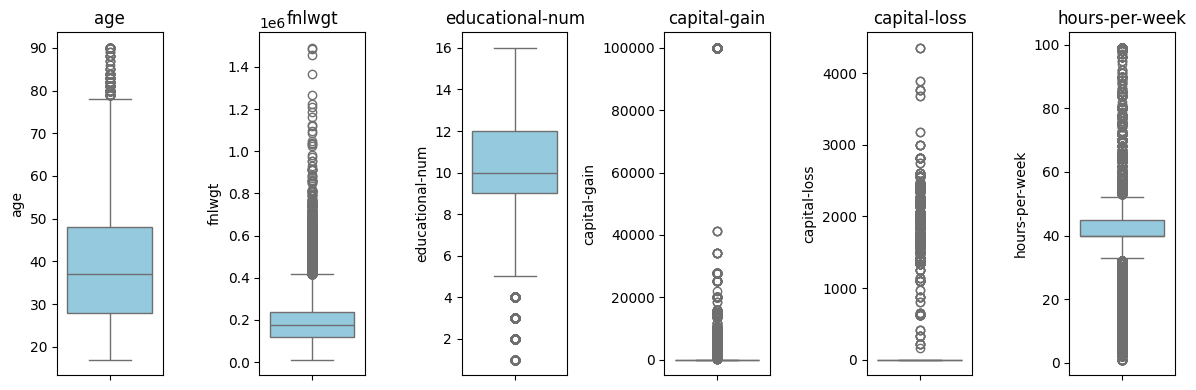

In [37]:
# Checking Outliers in Individual Features
x = 0
#Numerical features;
numeric_columns = df.select_dtypes(include=['number']).columns

# Create a figure with specified size
plt.figure(figsize=(16, 4))

for col in numeric_columns:
    x += 1
    plt.subplot(1, 8, x)
    sns.boxplot(data=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

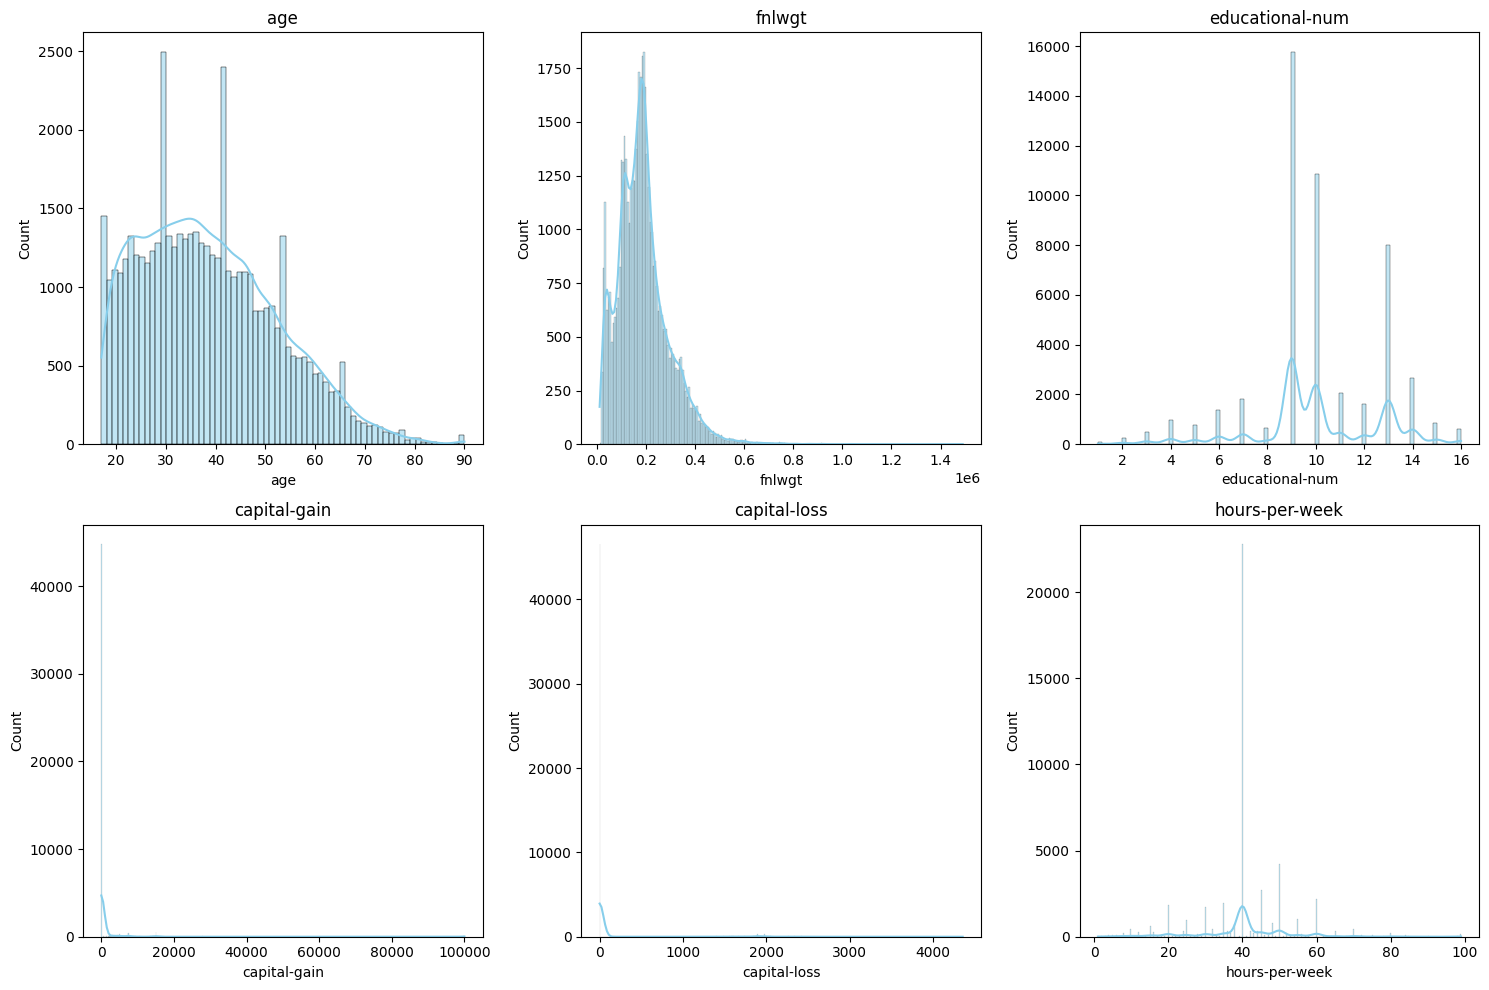

In [38]:
columns = numeric_columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(columns):
    sns.histplot(df[column], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(column)

for i in range(len(columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

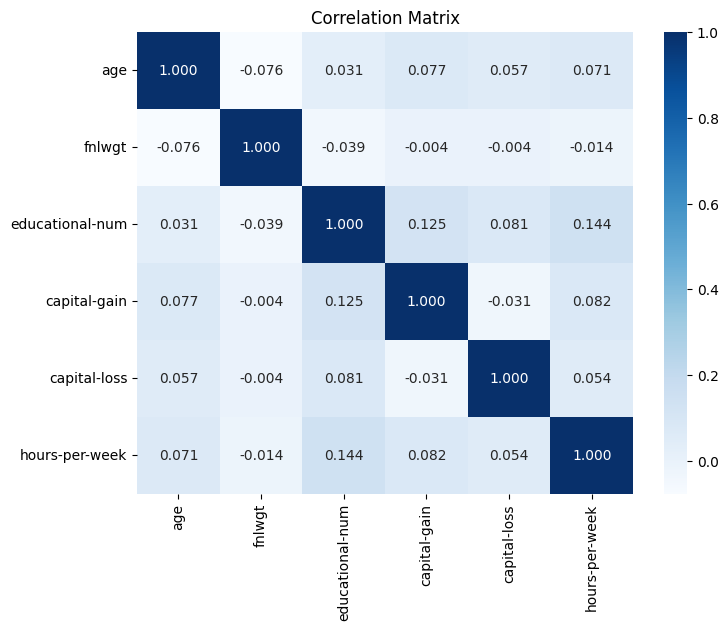

In [39]:
numeric_columns = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_columns.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".3f", cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

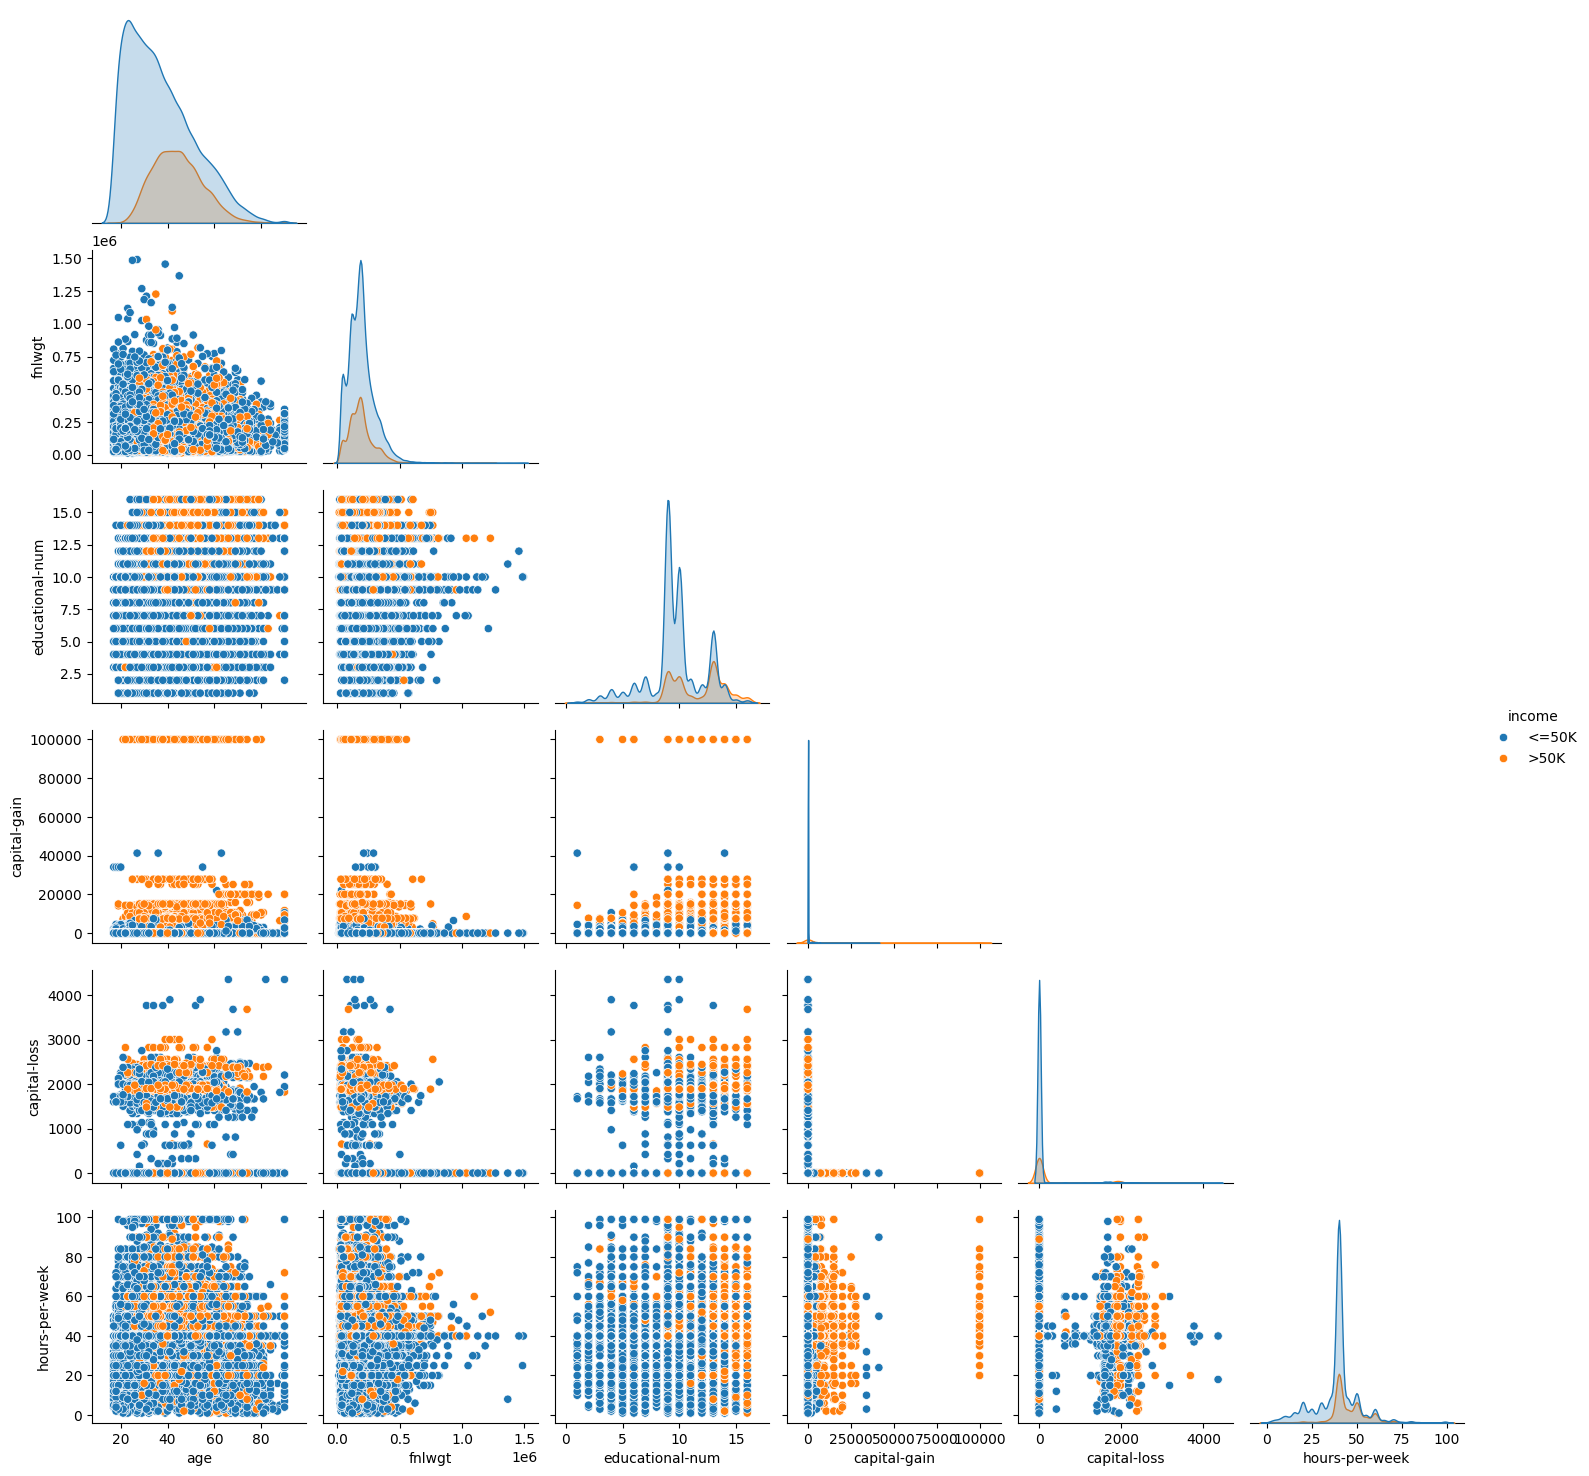

In [40]:
sns.pairplot(df, hue="income", corner=True);

<h2 id="eda3" style="color: skyblue;">NaN Values</h2>

In [41]:
df.isnull().sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64

In [42]:
print("Total number of NaN values:", df.isnull().sum().sum())
print("NaN values ​​are ", round((df.isnull().sum().sum() / len(df)) * 100, 3), "% of the data set.")

Total number of NaN values: 6456
NaN values ​​are  13.232 % of the data set.


<h3 id="nan1" style="color: steelblue;">NaN Values In "workclass" Column</h3>

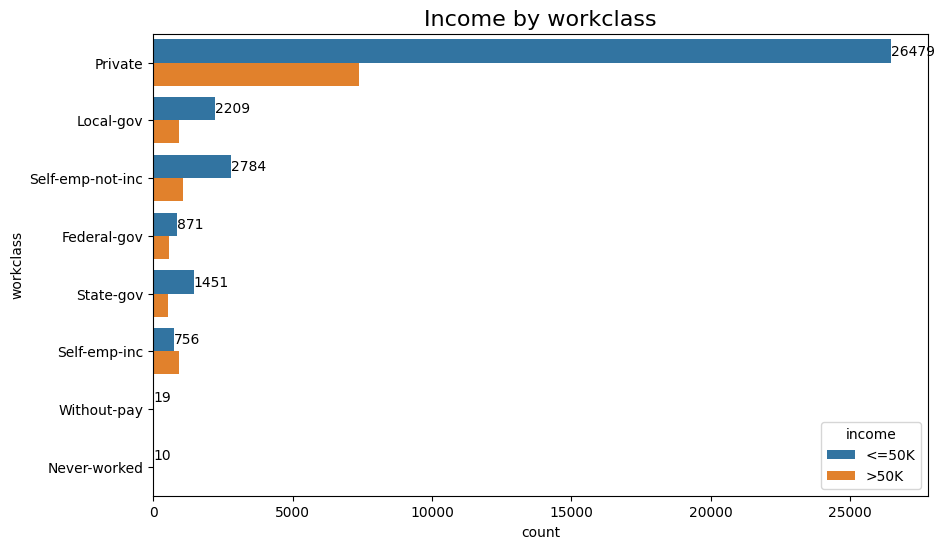

In [43]:
plt.figure(figsize = (10,6))
ax = sns.countplot(y = df['workclass'], hue = df['income'])
plt.title("Income by workclass", fontsize = 16)
ax.bar_label(ax.containers[0]);

In [44]:
df['workclass'] = df['workclass'].fillna('Private')

In [45]:
df.workclass.isnull().sum()

np.int64(0)

<h3 id="nan2" style="color: steelblue;">NaN Values In "occupation" Column</h3>

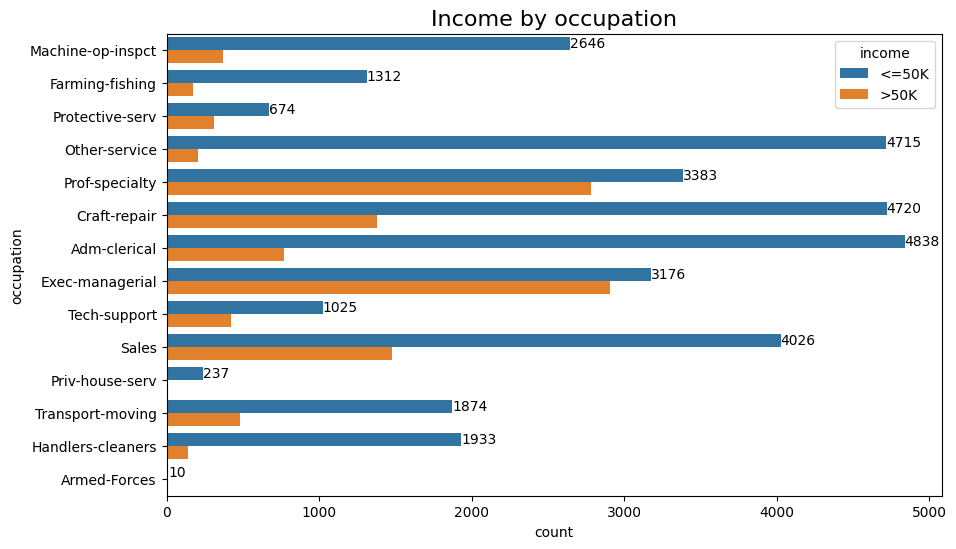

In [46]:
plt.figure(figsize = (10,6))
ax = sns.countplot(y = df['occupation'], hue = df['income'])
plt.title("Income by occupation", fontsize = 16)
ax.bar_label(ax.containers[0]);

In [47]:
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

In [48]:
df.occupation.isnull().sum()

np.int64(0)

<h3 id="nan3" style="color: steelblue;">NaN Values In "native-country" Column</h3>

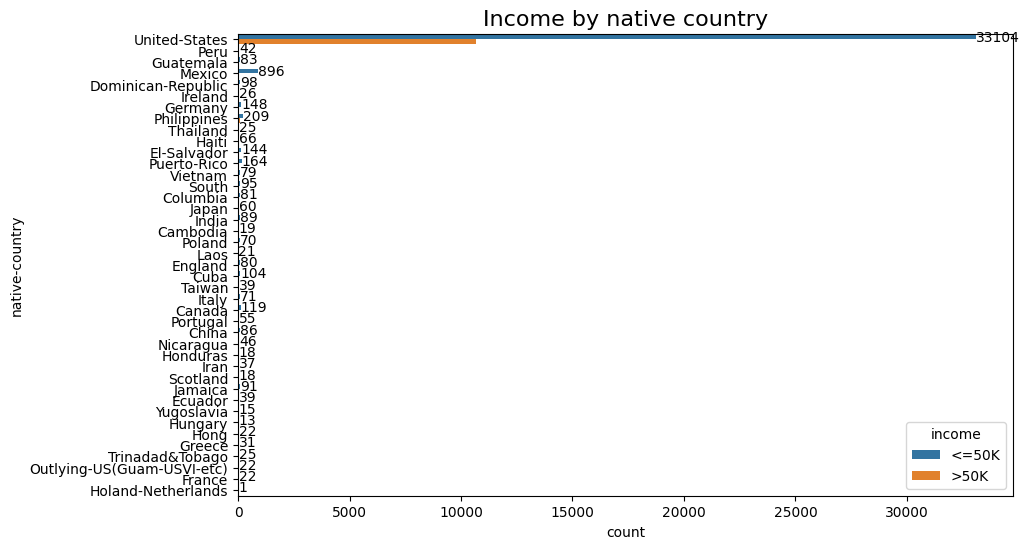

In [49]:
plt.figure(figsize = (10,6))
ax = sns.countplot(y = df['native-country'], hue = df['income'])
plt.title("Income by native country", fontsize = 16)
ax.bar_label(ax.containers[0]);

In [50]:
df['native-country'] = df['native-country'].fillna('United-States')

In [51]:
df['native-country'].isnull().sum()

np.int64(0)

In [52]:
df.isnull().sum().sum()

np.int64(0)

<h2 id="eda4" style="color: skyblue;">Outliers</h2>

<h3 id="outlier1" style="color: steelblue;">"hours-per-week" Column</h3>

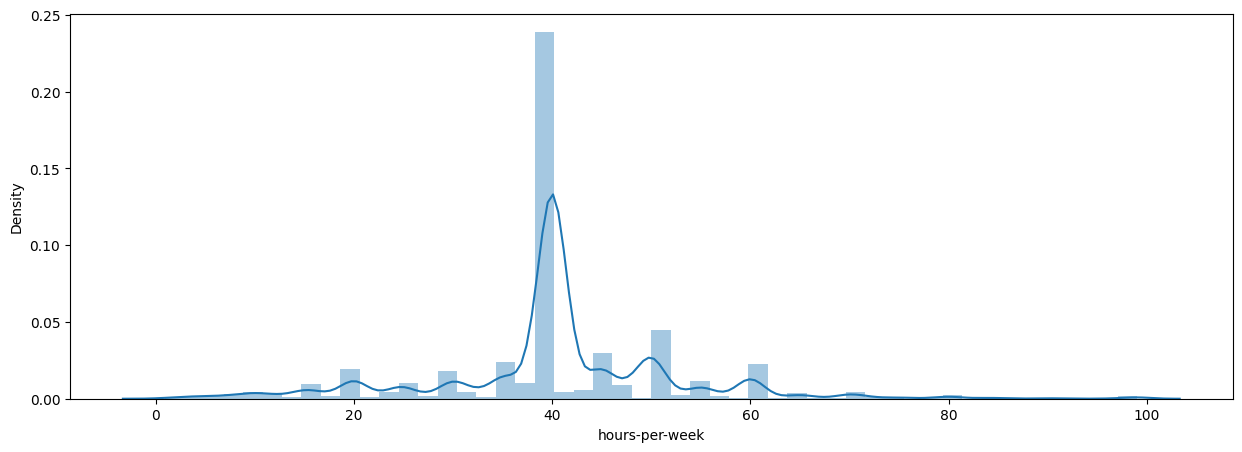

____________________________________________________________________________________________________
skewness in age column : 0.23965170789883736


In [53]:
# Doing univariate analysis on workours column
plt.figure(figsize = (15,5))
sns.distplot(df["hours-per-week"], kde = True)

plt.show()
print("_"*100)
print("skewness in age column :",df["hours-per-week"].skew());

In [54]:
Q1 = df["hours-per-week"].quantile(0.25)
Q3 = df["hours-per-week"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR
df = df[df["hours-per-week"].between(lower, upper)]

<h3 id="outlier2" style="color: steelblue;">"capital-gain" & "capital-loss" Columns</h3>

In [55]:
df['capital_diff'] = df['capital-gain'] - df['capital-loss']
df['capital_diff'] = pd.cut(df['capital_diff'], bins = [-5000, 5000, 100000], labels = ['Low', 'High'])
df['capital_diff'] = df['capital_diff'].astype('object')
df.drop(['capital-gain'], axis = 1, inplace = True)
df.drop(['capital-loss'], axis = 1, inplace = True)

def cap_outliers(df, lower_percentile=0.05, upper_percentile=0.95):
    for column in df.select_dtypes(include=np.number):  # Only apply to numeric columns
        lower_bound = df[column].quantile(lower_percentile)
        upper_bound = df[column].quantile(upper_percentile)
        df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

cap_outliers(df)

<h3 id="outlier3" style="color: steelblue;">"fnlwgt" Column</h3>

In [56]:
df.drop(labels = ["fnlwgt"],axis = 1,inplace = True)

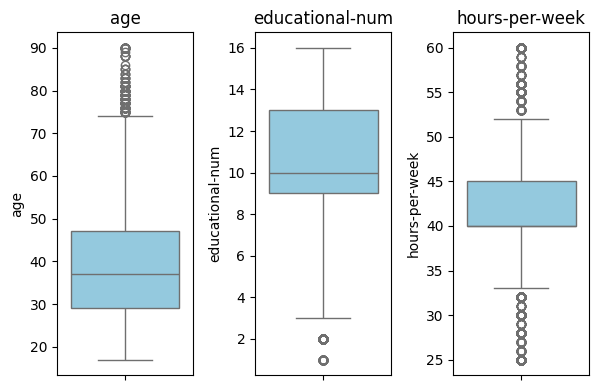

In [57]:
# Checking Outliers in Individual Features
x = 0
#Numerical features;
numeric_columns = df.select_dtypes(include=['number']).columns

# Create a figure with specified size
plt.figure(figsize=(16, 4))

for col in numeric_columns:
    x += 1
    plt.subplot(1, 8, x)
    sns.boxplot(data=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [58]:
# Cek korelasi education-num vs education
print(df.groupby('education')['educational-num'].mean().sort_values())
# Hasilnya akan hampir 1-to-1 mapping → hapus 'education', pertahankan 'education-num'

education
Preschool        1.0
1st-4th          2.0
5th-6th          3.0
7th-8th          4.0
9th              5.0
10th             6.0
11th             7.0
12th             8.0
HS-grad          9.0
Some-college    10.0
Assoc-voc       11.0
Assoc-acdm      12.0
Bachelors       13.0
Masters         14.0
Prof-school     15.0
Doctorate       16.0
Name: educational-num, dtype: float64


[Text(0, 0, '5358'),
 Text(0, 0, '9611'),
 Text(0, 0, '9938'),
 Text(0, 0, '4306'),
 Text(0, 0, '987'),
 Text(0, 0, '1229')]

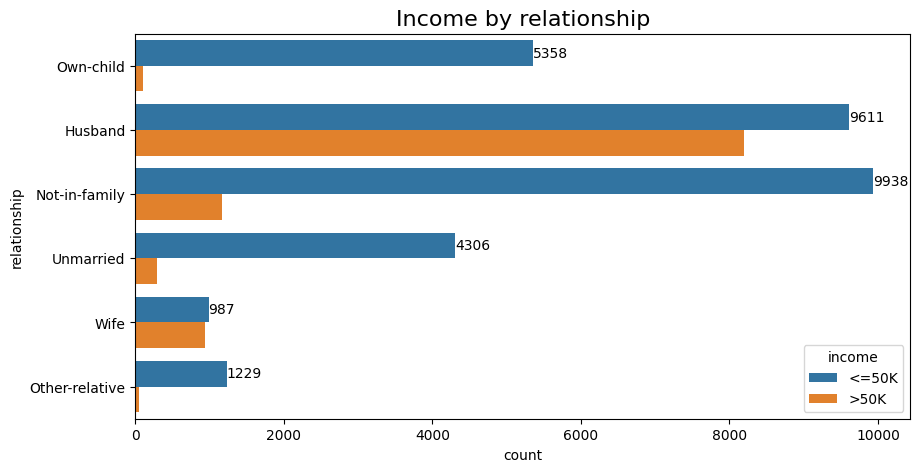

In [59]:
plt.figure(figsize=(10,5))
ax = sns.countplot(y=df['relationship'], hue=df['income'])
plt.title("Income by relationship", fontsize=16)
ax.bar_label(ax.containers[0])

<h2 id="eda5" style="color: skyblue;">Feature Engineering</h2>

In [60]:
# Removing rows where 'Workclass' is 'Without-pay' and 'Never-worked'
df = df[(df["workclass"] != "Without-pay") & (df["workclass"] != "Never-worked")]

In [61]:
df.drop(columns=['education'], inplace=True)

In [62]:
df.drop(columns=['relationship'], inplace=True)

In [63]:
df["race"].replace(["Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"],"Others", inplace = True)

0        Black
1        White
2        White
3        Black
4        White
         ...  
48836    White
48837    White
48838    White
48839    White
48841    White
Name: race, Length: 42146, dtype: str

In [64]:
df["native-country"].loc[df["native-country"] != "United-States"] = "Others"

In [65]:
df["marital-status"] = df["marital-status"].replace({
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Separated": "Married",
    "Never-married": "Single",
    "Divorced": "Single",
    "Widowed": "Single"
})

In [66]:
df['income']=df['income'].map({'<=50K': 0, '>50K': 1})

In [67]:
from scipy.stats import zscore

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('income')
z_scores = df[numeric_cols].apply(zscore)
mask = (z_scores.abs() < 3).all(axis=1)
df = df[mask]
print(f"Sisa data setelah z-score filter: {len(df)}")

Sisa data setelah z-score filter: 41730


<h1 id="data-pre" style="color: steelblue;">Data Pre-Processing</h1>

<h2 id="datapre1" style="color: skyblue;">Train | Test Split</h2>

In [68]:
df.income.value_counts()

# <=50 : 0
# >50 : 1

# Unbalanced data

income
0    31038
1    10692
Name: count, dtype: int64

In [69]:
X = df.drop(columns="income")
y = df.income

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

<h2 id="datapre2" style="color: skyblue;">Encoding</h2>

In [71]:
cat_onehot = ['workclass', 'occupation', 'race', 'gender', 'native-country', 'marital-status']
cat_ordinal = ['capital_diff']
cat_for_capdiff = ['Low', 'High']

In [72]:
column_trans = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_onehot),
                                       (OrdinalEncoder(categories= [cat_for_capdiff]), cat_ordinal),
                                       remainder='passthrough')

In [73]:
# Make copies to apply transformations locally within this cell
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Re-apply race replacement
X_train_processed["race"] = X_train_processed["race"].replace(["Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"],"Others")
X_test_processed["race"] = X_test_processed["race"].replace(["Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"],"Others")

# Re-apply native-country replacement
X_train_processed["native-country"] = X_train_processed["native-country"].apply(lambda x: "Others" if x != "United-States" else x)
X_test_processed["native-country"] = X_test_processed["native-country"].apply(lambda x: "Others" if x != "United-States" else x)

# Re-apply marital-status replacement
marital_status_replacements = {
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Separated": "Married",
    "Never-married": "Single",
    "Divorced": "Single",
    "Widowed": "Single"
}
X_train_processed["marital-status"] = X_train_processed["marital-status"].replace(marital_status_replacements)
X_test_processed["marital-status"] = X_test_processed["marital-status"].replace(marital_status_replacements)

X_train_trans = column_trans.fit_transform(X_train_processed)
X_test_trans = column_trans.transform(X_test_processed)

In [74]:
column_trans.get_feature_names_out()

array(['onehotencoder__workclass_Federal-gov',
       'onehotencoder__workclass_Local-gov',
       'onehotencoder__workclass_Private',
       'onehotencoder__workclass_Self-emp-inc',
       'onehotencoder__workclass_Self-emp-not-inc',
       'onehotencoder__workclass_State-gov',
       'onehotencoder__occupation_Adm-clerical',
       'onehotencoder__occupation_Armed-Forces',
       'onehotencoder__occupation_Craft-repair',
       'onehotencoder__occupation_Exec-managerial',
       'onehotencoder__occupation_Farming-fishing',
       'onehotencoder__occupation_Handlers-cleaners',
       'onehotencoder__occupation_Machine-op-inspct',
       'onehotencoder__occupation_Other-service',
       'onehotencoder__occupation_Priv-house-serv',
       'onehotencoder__occupation_Prof-specialty',
       'onehotencoder__occupation_Protective-serv',
       'onehotencoder__occupation_Sales',
       'onehotencoder__occupation_Tech-support',
       'onehotencoder__occupation_Transport-moving',
       'oneh

In [75]:
features = column_trans.get_feature_names_out()

In [76]:
X_train= pd.DataFrame(X_train_trans, columns=features, index=X_train.index)
X_train.head()

,onehotencoder__workclass_Federal-gov,onehotencoder__workclass_Local-gov,onehotencoder__workclass_Private,onehotencoder__workclass_Self-emp-inc,onehotencoder__workclass_Self-emp-not-inc,onehotencoder__workclass_State-gov,onehotencoder__occupation_Adm-clerical,onehotencoder__occupation_Armed-Forces,onehotencoder__occupation_Craft-repair,onehotencoder__occupation_Exec-managerial,...,onehotencoder__gender_Female,onehotencoder__gender_Male,onehotencoder__native-country_Others,onehotencoder__native-country_United-States,onehotencoder__marital-status_Married,onehotencoder__marital-status_Single,ordinalencoder__capital_diff,remainder__age,remainder__educational-num,remainder__hours-per-week
8880,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,65.0,9.0,40.0
46129,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,41.0,9.0,40.0
37133,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,26.0,9.0,40.0
36995,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,49.0,9.0,50.0
26438,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,24.0,10.0,40.0


In [77]:
X_test= pd.DataFrame(X_test_trans, columns=features, index=X_test.index)
X_test.head()

,onehotencoder__workclass_Federal-gov,onehotencoder__workclass_Local-gov,onehotencoder__workclass_Private,onehotencoder__workclass_Self-emp-inc,onehotencoder__workclass_Self-emp-not-inc,onehotencoder__workclass_State-gov,onehotencoder__occupation_Adm-clerical,onehotencoder__occupation_Armed-Forces,onehotencoder__occupation_Craft-repair,onehotencoder__occupation_Exec-managerial,...,onehotencoder__gender_Female,onehotencoder__gender_Male,onehotencoder__native-country_Others,onehotencoder__native-country_United-States,onehotencoder__marital-status_Married,onehotencoder__marital-status_Single,ordinalencoder__capital_diff,remainder__age,remainder__educational-num,remainder__hours-per-week
9832,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,30.0,13.0,50.0
31492,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,36.0,11.0,42.0
22458,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,40.0,13.0,40.0
35709,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,41.0,5.0,40.0
18820,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,27.0,9.0,40.0


In [78]:
correlation = df.corr(numeric_only=True)['income'].sort_values(ascending=False)

print("Income correlations:")
print(correlation[:])


Income correlations:
income             1.000000
educational-num    0.335471
age                0.255064
hours-per-week     0.237177
Name: income, dtype: float64


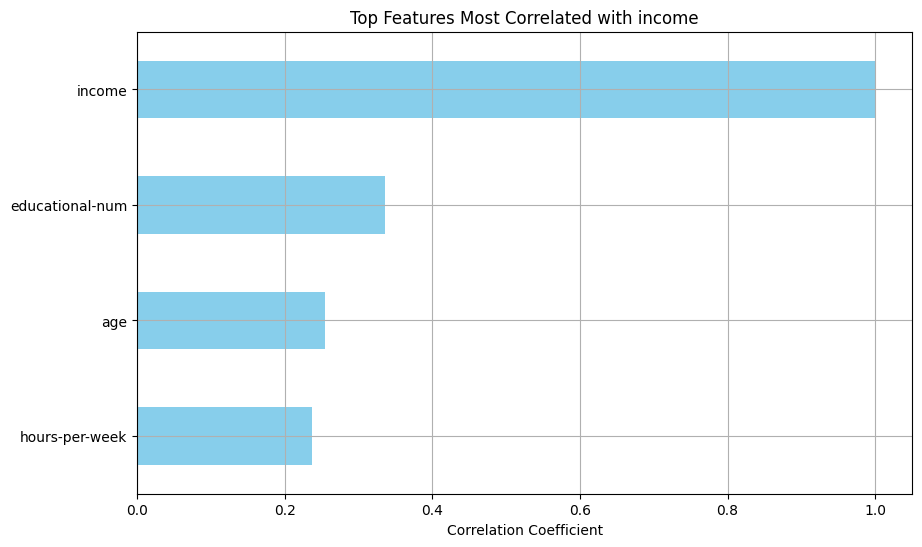

In [79]:
top_features = correlation[:]
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='skyblue')
plt.title('Top Features Most Correlated with income')
plt.xlabel('Correlation Coefficient')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Heatmap of Top Features Correlated with SalePrice')

<Figure size 1000x600 with 0 Axes>

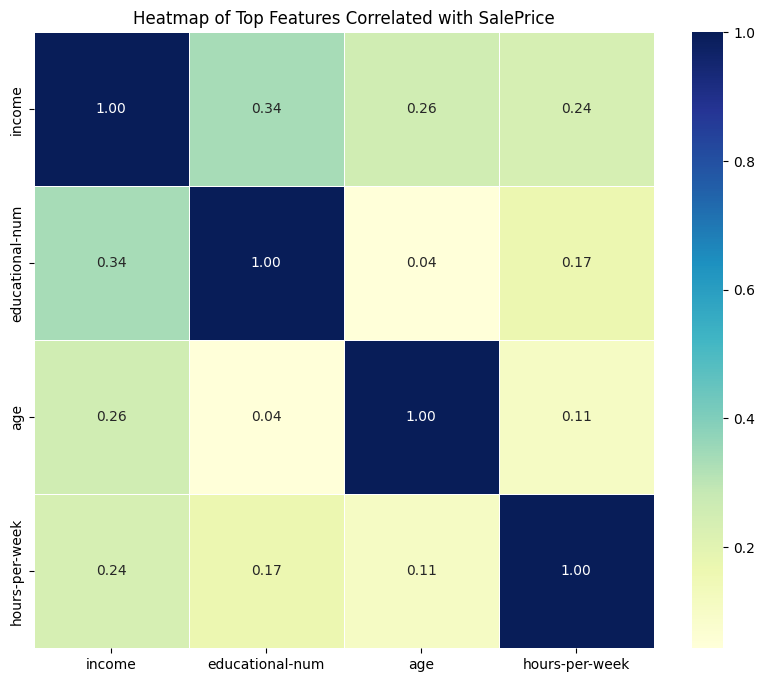

In [80]:
plt.figure(figsize=(10, 6))
corr_matrix = df.corr(numeric_only=True)

top_corr_features = corr_matrix['income'].abs().sort_values(ascending=False)[:].index

top_corr_matrix = df[top_corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Top Features Correlated with SalePrice')

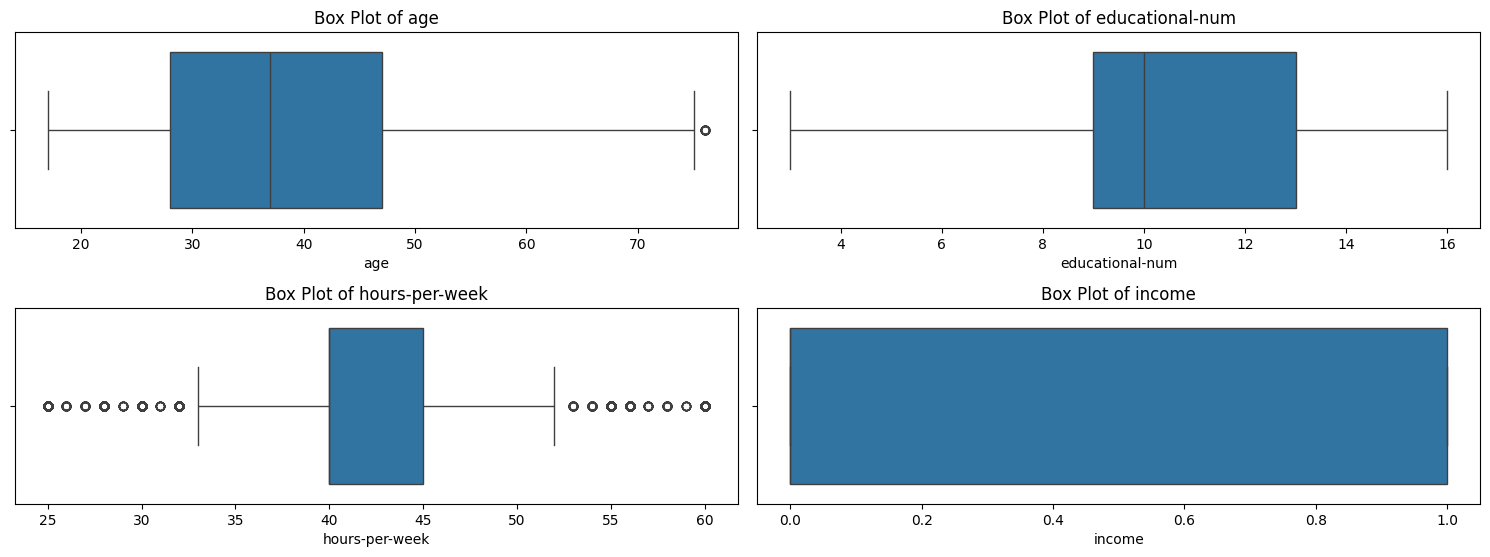

In [81]:
numeric_columns = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, len(numeric_columns)*2))


for i, col in enumerate(numeric_columns):
    plt.subplot(len(numeric_columns)//2 + 1, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

In [82]:
x =df.drop('income' , axis=1)
y =df['income']

In [83]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numeric_cols_idx = [i for i, col in enumerate(X_train.columns)
                   if X_train[col].dtype in ['float64', 'int64']]

X_train[X_train.columns[numeric_cols_idx]] = scaler.fit_transform(
    X_train.iloc[:, numeric_cols_idx])
X_test[X_test.columns[numeric_cols_idx]] = scaler.transform(
    X_test.iloc[:, numeric_cols_idx])

In [84]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [85]:
from collections import Counter

print("Sebelum SMOTE:", Counter(y_train))
print("Sesudah SMOTE:", Counter(y_train_resampled))

Sebelum SMOTE: Counter({0: 24830, 1: 8554})
Sesudah SMOTE: Counter({0: 24830, 1: 24830})


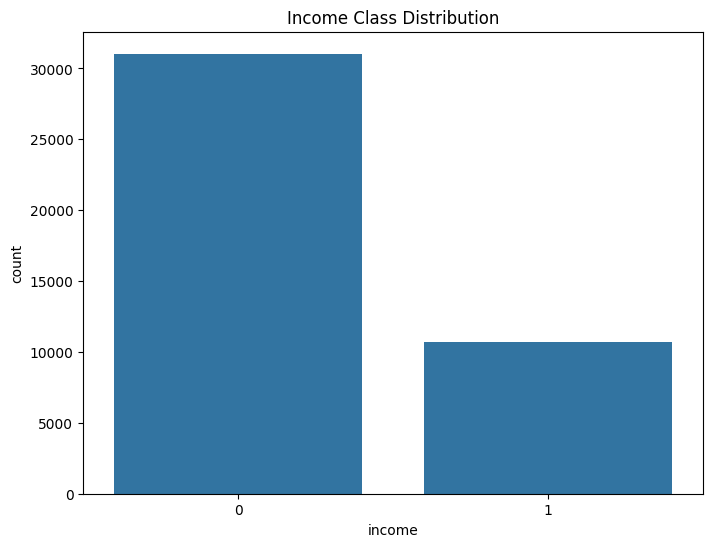

In [86]:
y_df=pd.DataFrame(y)
sns.countplot(data=y_df, x='income')
plt.title('Income Class Distribution')
plt.show()

In [87]:
from sklearn.naive_bayes import  GaussianNB
from sklearn.metrics import classification_report, confusion_matrix


Training Gaussian Naive Bayes...


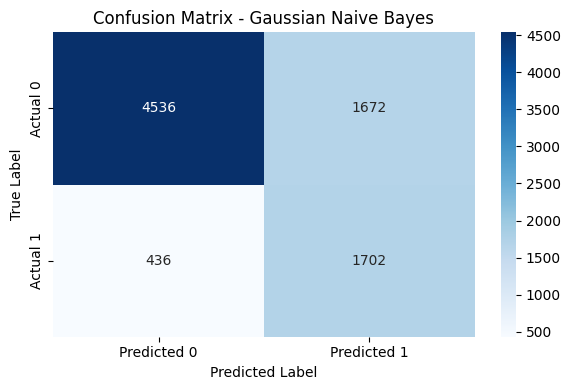


Classification Report for Gaussian Naive Bayes:

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      6208
           1       0.50      0.80      0.62      2138

    accuracy                           0.75      8346
   macro avg       0.71      0.76      0.71      8346
weighted avg       0.81      0.75      0.76      8346



In [88]:
models = {
    "Gaussian Naive Bayes": GaussianNB()
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_resampled, y_train_resampled)

    y_prob = model.predict_proba(X_test)[:,1]

    threshold = 0.7  # coba 0.6 - 0.8
    y_pred = (y_prob > threshold).astype(int)

    labels = np.unique(y_test)

    conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)
    conf_matrix_df = pd.DataFrame(conf_matrix,
                                  columns=[f"Predicted {label}" for label in labels],
                                  index=[f"Actual {label}" for label in labels])

    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_test, y_pred))


Training Gaussian Naive Bayes...
Threshold optimal: 0.989


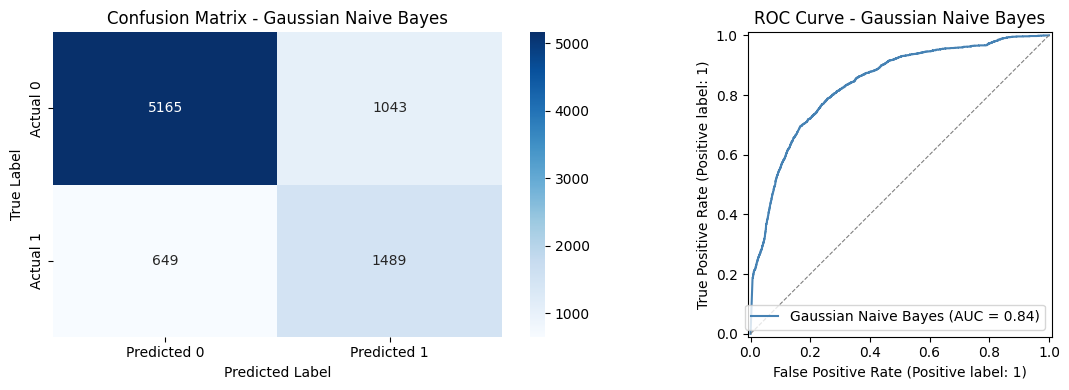


Classification Report (threshold=0.989):

              precision    recall  f1-score   support

       <=50K       0.89      0.83      0.86      6208
        >50K       0.59      0.70      0.64      2138

    accuracy                           0.80      8346
   macro avg       0.74      0.76      0.75      8346
weighted avg       0.81      0.80      0.80      8346

ROC-AUC Score: 0.8378


In [89]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score,
                             RocCurveDisplay)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Gaussian Naive Bayes": GaussianNB()
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_resampled, y_train_resampled)

    y_prob = model.predict_proba(X_test)[:, 1]

    # Cari threshold optimal dari precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    print(f"Threshold optimal: {optimal_threshold:.3f}")

    y_pred = (y_prob >= optimal_threshold).astype(int)

    # Confusion matrix
    labels = np.unique(y_test)
    conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)
    conf_matrix_df = pd.DataFrame(conf_matrix,
                                  columns=[f"Predicted {l}" for l in labels],
                                  index=[f"Actual {l}" for l in labels])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.heatmap(conf_matrix_df, annot=True, fmt='d',
                cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix - {name}')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                     name=name, color='steelblue')
    axes[1].set_title(f'ROC Curve - {name}')
    axes[1].plot([0,1],[0,1],'--', color='gray', linewidth=0.8)

    plt.tight_layout()
    plt.show()

    # Metrics
    print(f"\nClassification Report (threshold={optimal_threshold:.3f}):\n")
    print(classification_report(y_test, y_pred,
                                target_names=['<=50K', '>50K']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Threshold optimal: 0.579


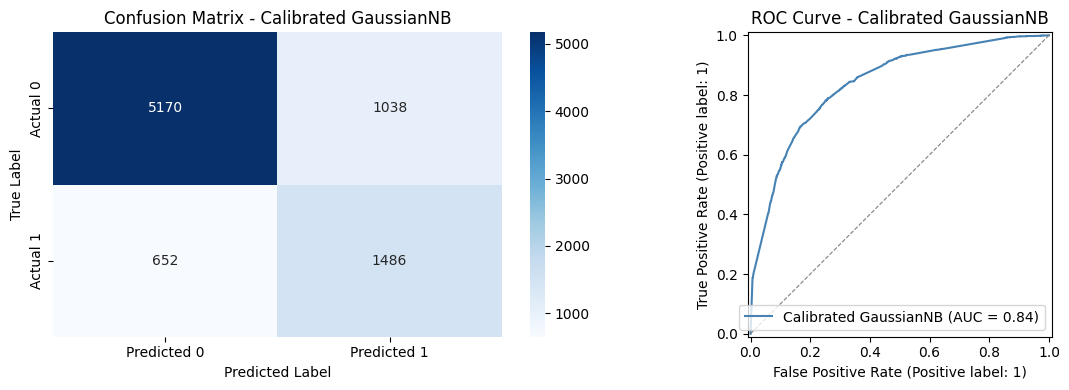


Classification Report (threshold=0.579):

              precision    recall  f1-score   support

       <=50K       0.89      0.83      0.86      6208
        >50K       0.59      0.70      0.64      2138

    accuracy                           0.80      8346
   macro avg       0.74      0.76      0.75      8346
weighted avg       0.81      0.80      0.80      8346

ROC-AUC Score: 0.8401


In [90]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score,
                             RocCurveDisplay)

# 1. Definisi model dengan kalibrasi
calibrated_gnb = CalibratedClassifierCV(GaussianNB(), cv=5, method='isotonic')

# 2. Training
calibrated_gnb.fit(X_train_resampled, y_train_resampled)

# 3. Prediksi probabilitas
y_prob_cal = calibrated_gnb.predict_proba(X_test)[:, 1]

# 4. Cari threshold optimal
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_cal)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Threshold optimal: {optimal_threshold:.3f}")

# 5. Prediksi final
y_pred_cal = (y_prob_cal >= optimal_threshold).astype(int)

# 6. Visualisasi
labels = np.unique(y_test)
conf_matrix = confusion_matrix(y_test, y_pred_cal, labels=labels)
conf_matrix_df = pd.DataFrame(conf_matrix,
                              columns=[f"Predicted {l}" for l in labels],
                              index=[f"Actual {l}" for l in labels])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(conf_matrix_df, annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Calibrated GaussianNB')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

RocCurveDisplay.from_predictions(y_test, y_prob_cal, ax=axes[1],
                                 name='Calibrated GaussianNB',
                                 color='steelblue')
axes[1].plot([0,1],[0,1],'--', color='gray', linewidth=0.8)
axes[1].set_title('ROC Curve - Calibrated GaussianNB')

plt.tight_layout()
plt.show()

# 7. Report
print(f"\nClassification Report (threshold={optimal_threshold:.3f}):\n")
print(classification_report(y_test, y_pred_cal,
                            target_names=['<=50K', '>50K']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_cal):.4f}")

In [91]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.8378066745103334


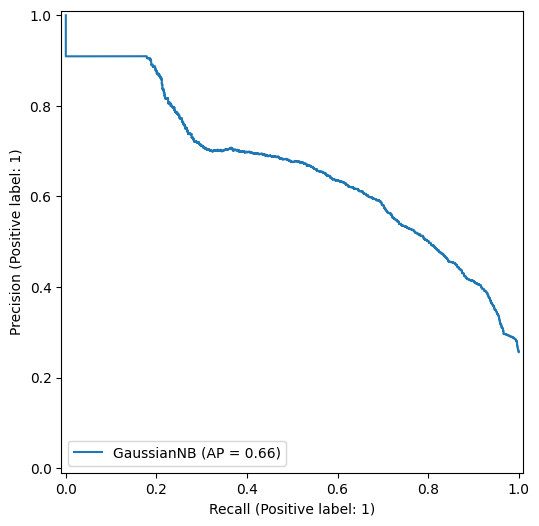

In [92]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(model, X_test, y_test)

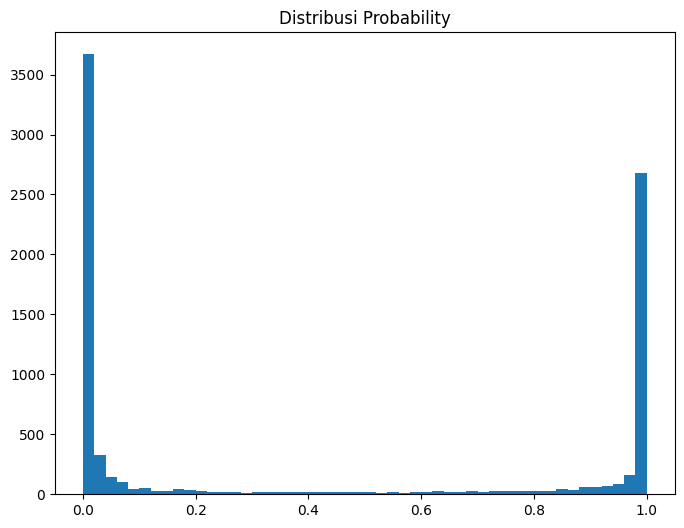

In [93]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=50)
plt.title("Distribusi Probability")
plt.show()

In [94]:
df.info()

<class 'pandas.DataFrame'>
Index: 41730 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              41730 non-null  int64 
 1   workclass        41730 non-null  str   
 2   educational-num  41730 non-null  int64 
 3   marital-status   41730 non-null  str   
 4   occupation       41730 non-null  str   
 5   race             41730 non-null  str   
 6   gender           41730 non-null  str   
 7   hours-per-week   41730 non-null  int64 
 8   native-country   41730 non-null  str   
 9   income           41730 non-null  int64 
 10  capital_diff     41730 non-null  object
dtypes: int64(4), object(1), str(6)
memory usage: 5.9+ MB
